In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import datetime
import seaborn as sns
import re
from shapely.geometry import Point, Polygon, MultiPolygon
import random
import os
from scipy.integrate import solve_ivp
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import string
import matplotlib.gridspec as gridspec
from scipy.stats import gamma
import scipy.stats as stats
from scipy.integrate import quad

# Set seed
np.random.seed(251214)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.rcParams['font.family']='Arial'

bar_width=0.25
plt.rc('axes', labelsize=10)
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=12) 
alphsize=12
alpha=0.4
padsize=15
set_dpi=300

In [ ]:
datafolder = "../Result/Revision_SI_over0_censoring/"
savefolder = "../Figure/Revision_SI_over0_censoring/"

color_list=['#3772ff','#f28482'] # Baloxavir treatment, No treatment

# Serial interval with Baloxavir or without treatment

In [6]:
df_si_balox = pd.read_excel(datafolder + "df_compare_SI_dist_IQR.xlsx", sheet_name="Baloxavir_Serial")
df_si_wotrt = pd.read_excel(datafolder + "df_compare_SI_dist_IQR.xlsx", sheet_name="NoTreatment_Serial")
df_si_mean = pd.read_excel(datafolder + "mean_serial_interval_IQR.xlsx")

In [ ]:
si_balox = df_si_balox['serial_numeric']
si_wotrt = df_si_wotrt['serial_numeric']

In [8]:
si_balox_mean = df_si_mean['lower_bound_mean_serial'][0]
si_wotrt_mean = df_si_mean['lower_bound_mean_serial'][1]

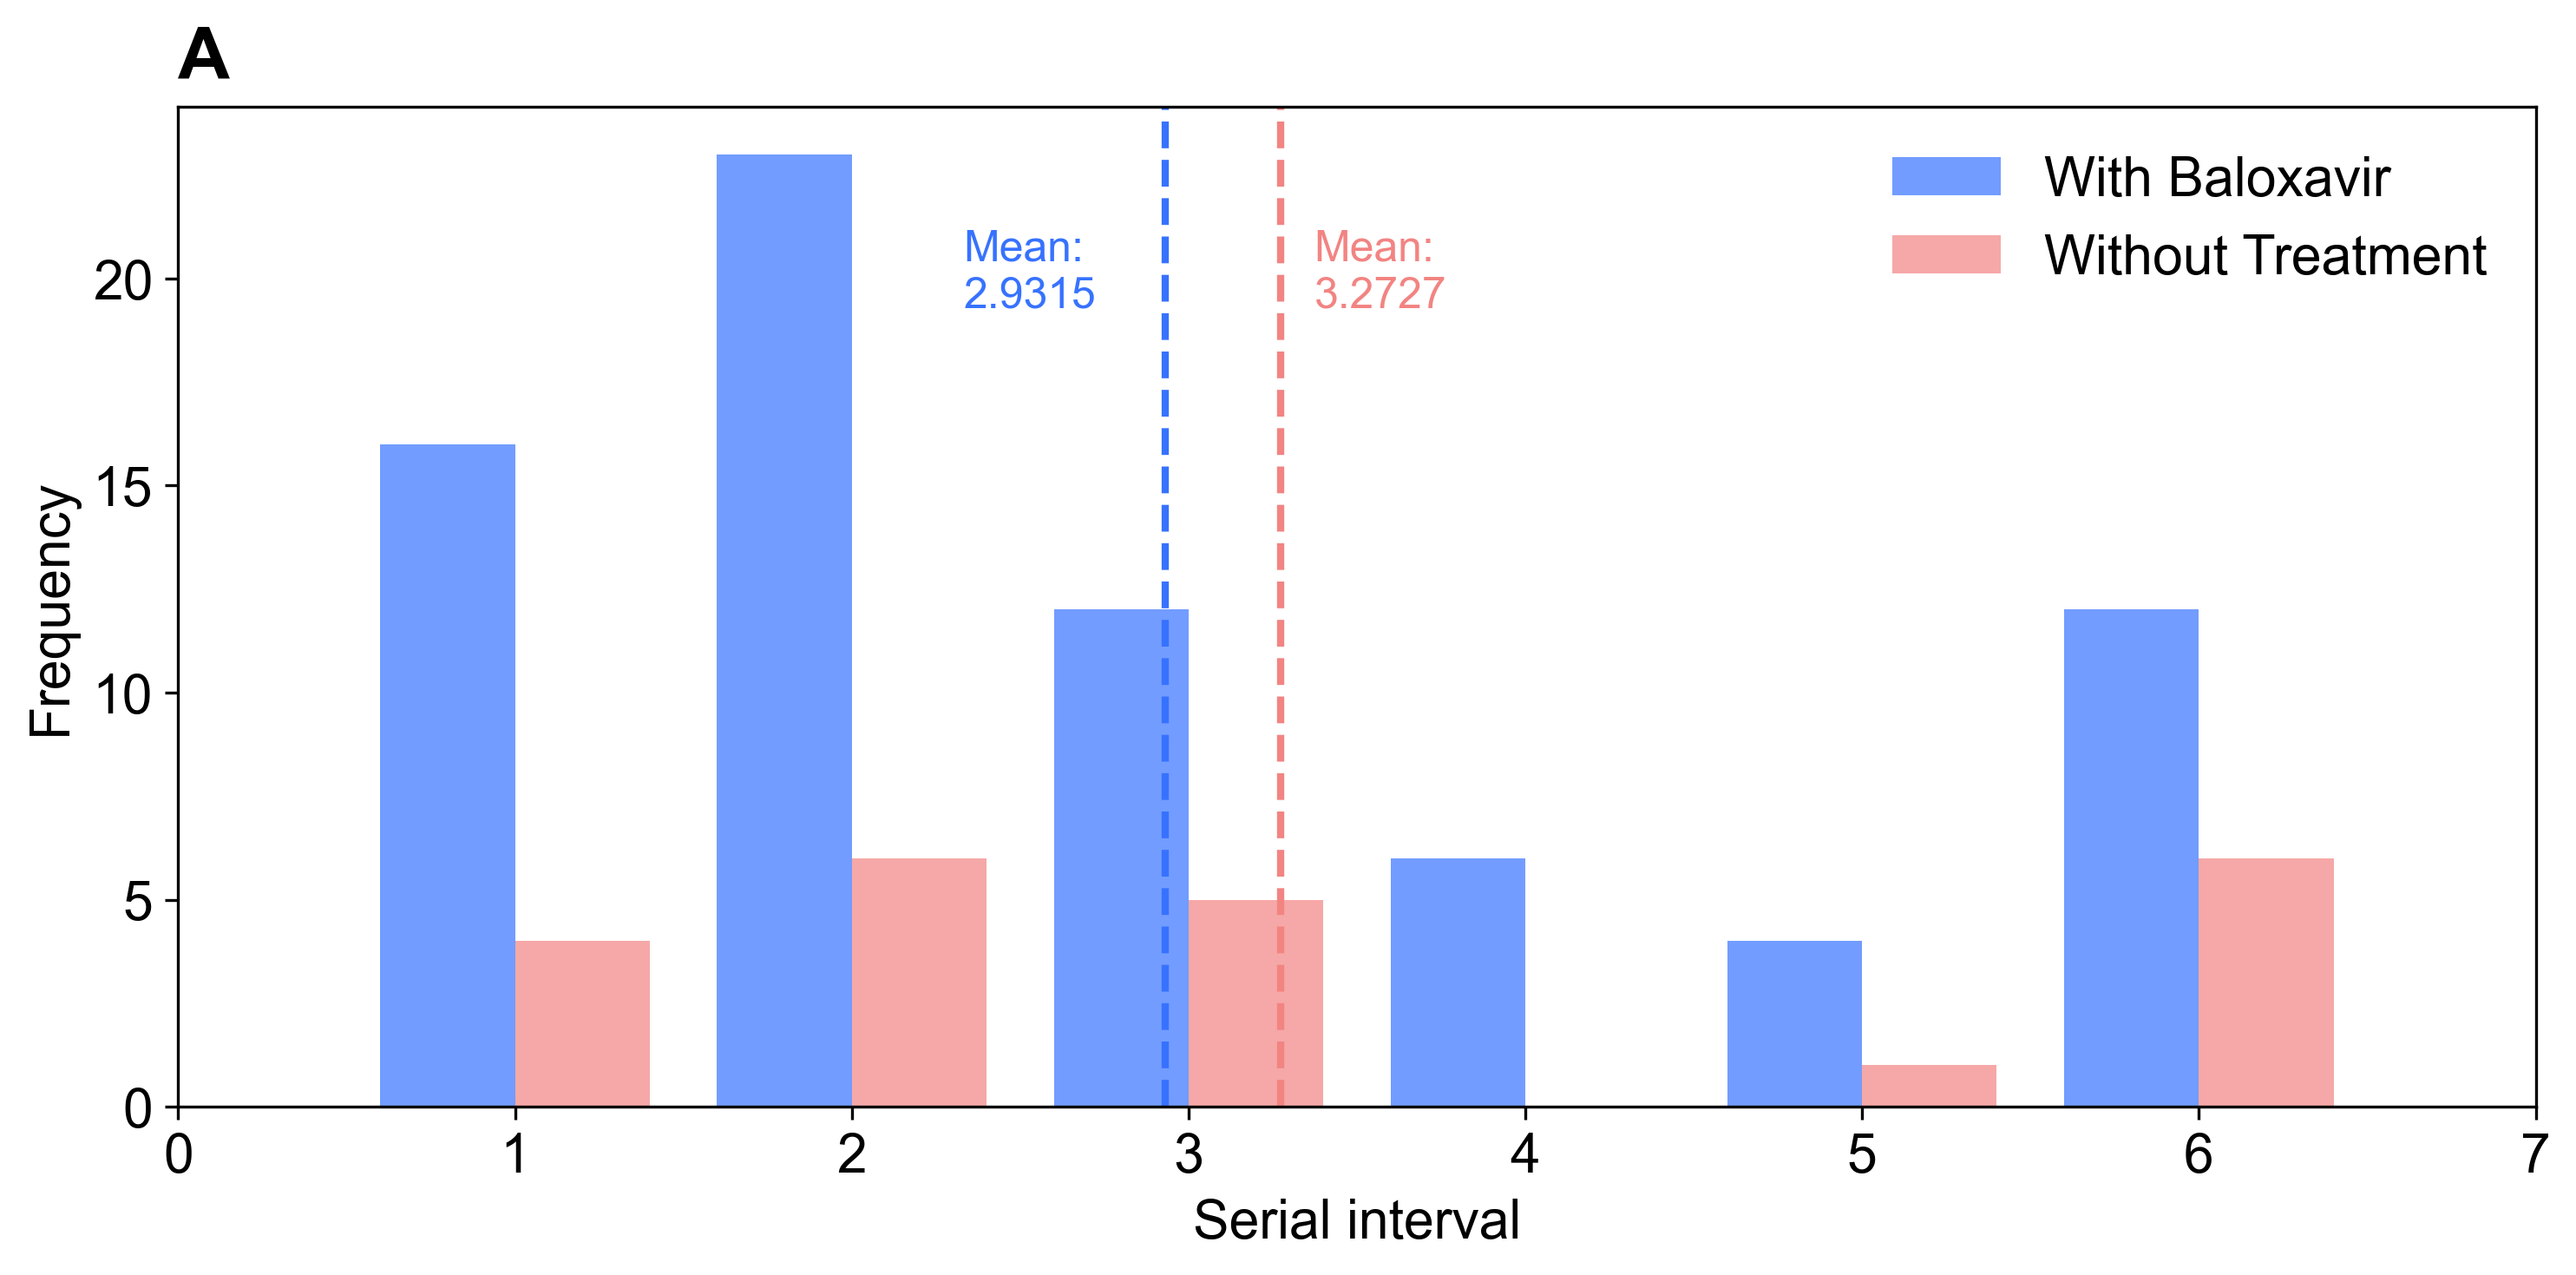

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,5), dpi=set_dpi)

bins = np.arange(-0.5, 15.5, 1)

ax1.hist([si_balox, si_wotrt], bins=bins, density=False, alpha=0.7, 
         color=[color_list[0], color_list[1]], 
         label=['With Baloxavir', 'Without Treatment'],
         align='mid')

ax1.set_xlabel('Serial interval', fontsize=15)
ax1.set_ylabel('Frequency', fontsize=15)
ax1.set_xticks(range(0, 9))
ax1.set_xlim(0, 7)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.text(0,1.03,'{}'.format(string.ascii_uppercase[0]),transform=ax1.transAxes,weight='bold',fontsize=20)
ax1.axvline(si_balox_mean, color=color_list[0], linestyle='--', linewidth=2)
ax1.axvline(si_wotrt_mean, color=color_list[1], linestyle='--', linewidth=2)
ax1.text(si_balox_mean-0.6, max(ax1.get_ylim())*0.8, 'Mean:\n{:.4f}'.format(si_balox_mean), color=color_list[0], fontsize=12)
ax1.text(si_wotrt_mean+0.1, max(ax1.get_ylim())*0.8, 'Mean:\n{:.4f}'.format(si_wotrt_mean), color=color_list[1], fontsize=12)
ax1.legend(loc='upper right', fontsize=15, frameon=False)

plt.tight_layout()
plt.show()

fig.savefig(savefolder+'FigS2.png', format='png', bbox_inches='tight', pad_inches=.1, dpi=set_dpi)


# Serial interval dist with Baloxavir treatment

In [ ]:
wotrt_serial_freq = si_wotrt.value_counts().sort_index().reset_index()
wotrt_serial_freq.columns = ['serial', 'Freq']

wtrt_serial_freq = si_balox.value_counts().sort_index().reset_index()
wtrt_serial_freq.columns = ['serial', 'Freq']

wotrt_serial_freq

,serial,Freq
0,1,4
1,2,6
2,3,5
3,5,1
4,6,6


In [ ]:
def g_pdf(s, g_par1, g_par2, dist_name):
    if s < 0:
        return 0
    
    if dist_name == "Gamma":
        return gamma.pdf(s, a=g_par1, scale=g_par2)
    elif dist_name == "Weibull":
        return weibull_min.pdf(s, c=g_par1, scale=g_par2)
    else:
        return 0

def g_prime_pdf_func_normalize(s_val, st, epsilon, g_par1, g_par2, dist_name):
    base_pdf = g_pdf(s_val, g_par1, g_par2, dist_name)
    
    # integrate(g, 0, st)
    int_1, _ = quad(lambda x: g_pdf(x, g_par1, g_par2, dist_name), 0, st)
    # integrate((1-epsilon)*g, st, Inf)
    int_2, _ = quad(lambda x: (1 - epsilon) * g_pdf(x, g_par1, g_par2, dist_name), st, np.inf)
    
    denominator = int_1 + int_2
    
    if denominator < 1e-9:
        return 0
    
    if s_val < st:
        numerator = base_pdf
    else:
        numerator = (1 - epsilon) * base_pdf
        
    return (numerator / denominator)

def g_prime_pdf_func(s_val, st, epsilon, g_par1, g_par2, dist_name):
    base_pdf = g_pdf(s_val, g_par1, g_par2, dist_name)
    
    # integrate(g, 0, st)
    int_1, _ = quad(lambda x: g_pdf(x, g_par1, g_par2, dist_name), 0, st)
    # integrate((1-epsilon)*g, st, Inf)
    int_2, _ = quad(lambda x: (1 - epsilon) * g_pdf(x, g_par1, g_par2, dist_name), st, np.inf)
    
    denominator = int_1 + int_2
    
    if denominator < 1e-9:
        return 0
    
    if s_val < st:
        numerator = base_pdf
    else:
        numerator = (1 - epsilon) * base_pdf
        
    return numerator

def get_g_prime_array_normalize(s_array, st, epsilon, g_par1, g_par2, dist_name):
    return np.array([g_prime_pdf_func_normalize(s, st, epsilon, g_par1, g_par2, dist_name) for s in s_array])

def get_g_prime_array(s_array, st, epsilon, g_par1, g_par2, dist_name):
    return np.array([g_prime_pdf_func(s, st, epsilon, g_par1, g_par2, dist_name) for s in s_array])


In [ ]:
from scipy.stats import weibull_min

best_model_df = pd.read_excel(datafolder + "Best_Model_Estimation_IQR.xlsx")
g_par1 = best_model_df['g_par1'].iloc[0]
g_par2 = best_model_df['g_par2'].iloc[0]
epsilon = best_model_df['epsilon'].iloc[0]
dist_name = best_model_df['Distribution'].iloc[0]

x = np.linspace(0, 10, 1000)

if dist_name == "Gamma":
    g_values = gamma.pdf(x, a=g_par1, scale=g_par2)
elif dist_name == "Weibull":
    g_values = weibull_min.pdf(x, c=g_par1, scale=g_par2)

taus = df_si_balox['delay'].unique()
taus = np.sort(taus)
taus
combined_data_list = []

combined_data_list.append(pd.DataFrame({
    's': x, 
    'density': g_values,
    'density_norm': g_values,
    'Type': 'g(s) (No Treatment)'
}))

# 각 tau별 g'(s)
for t in taus:
    gp_val_norm = get_g_prime_array_normalize(x, t, epsilon, g_par1, g_par2, dist_name)
    gp_val = get_g_prime_array(x, t, epsilon, g_par1, g_par2, dist_name)
    combined_data_list.append(pd.DataFrame({
        's': x,
        'density': gp_val,
        'density_norm': gp_val_norm,
        'Type': f"g'(s), delay={t}"
    }))

df_all_combined = pd.concat(combined_data_list, ignore_index=True)

In [ ]:
si_delay1 = df_si_balox[df_si_balox['delay'] == 1]['serial_numeric']
si_delay2 = df_si_balox[df_si_balox['delay'] == 2]['serial_numeric']
si_delay3 = df_si_balox[df_si_balox['delay'] == 3]['serial_numeric']
si_delay4 = df_si_balox[df_si_balox['delay'] == 4]['serial_numeric']

In [16]:
plot_type = df_all_combined['Type'].unique()
plot_title = [f'$g_{{trt}}(s)$', f'$g_{{trt}}(s)$', f'$g_{{trt}}(s)$']
plot_color = ["#6d110f", "#9b37ff", "#185935"] # , '#90be6d', "#ecb433" , '#f3722c'

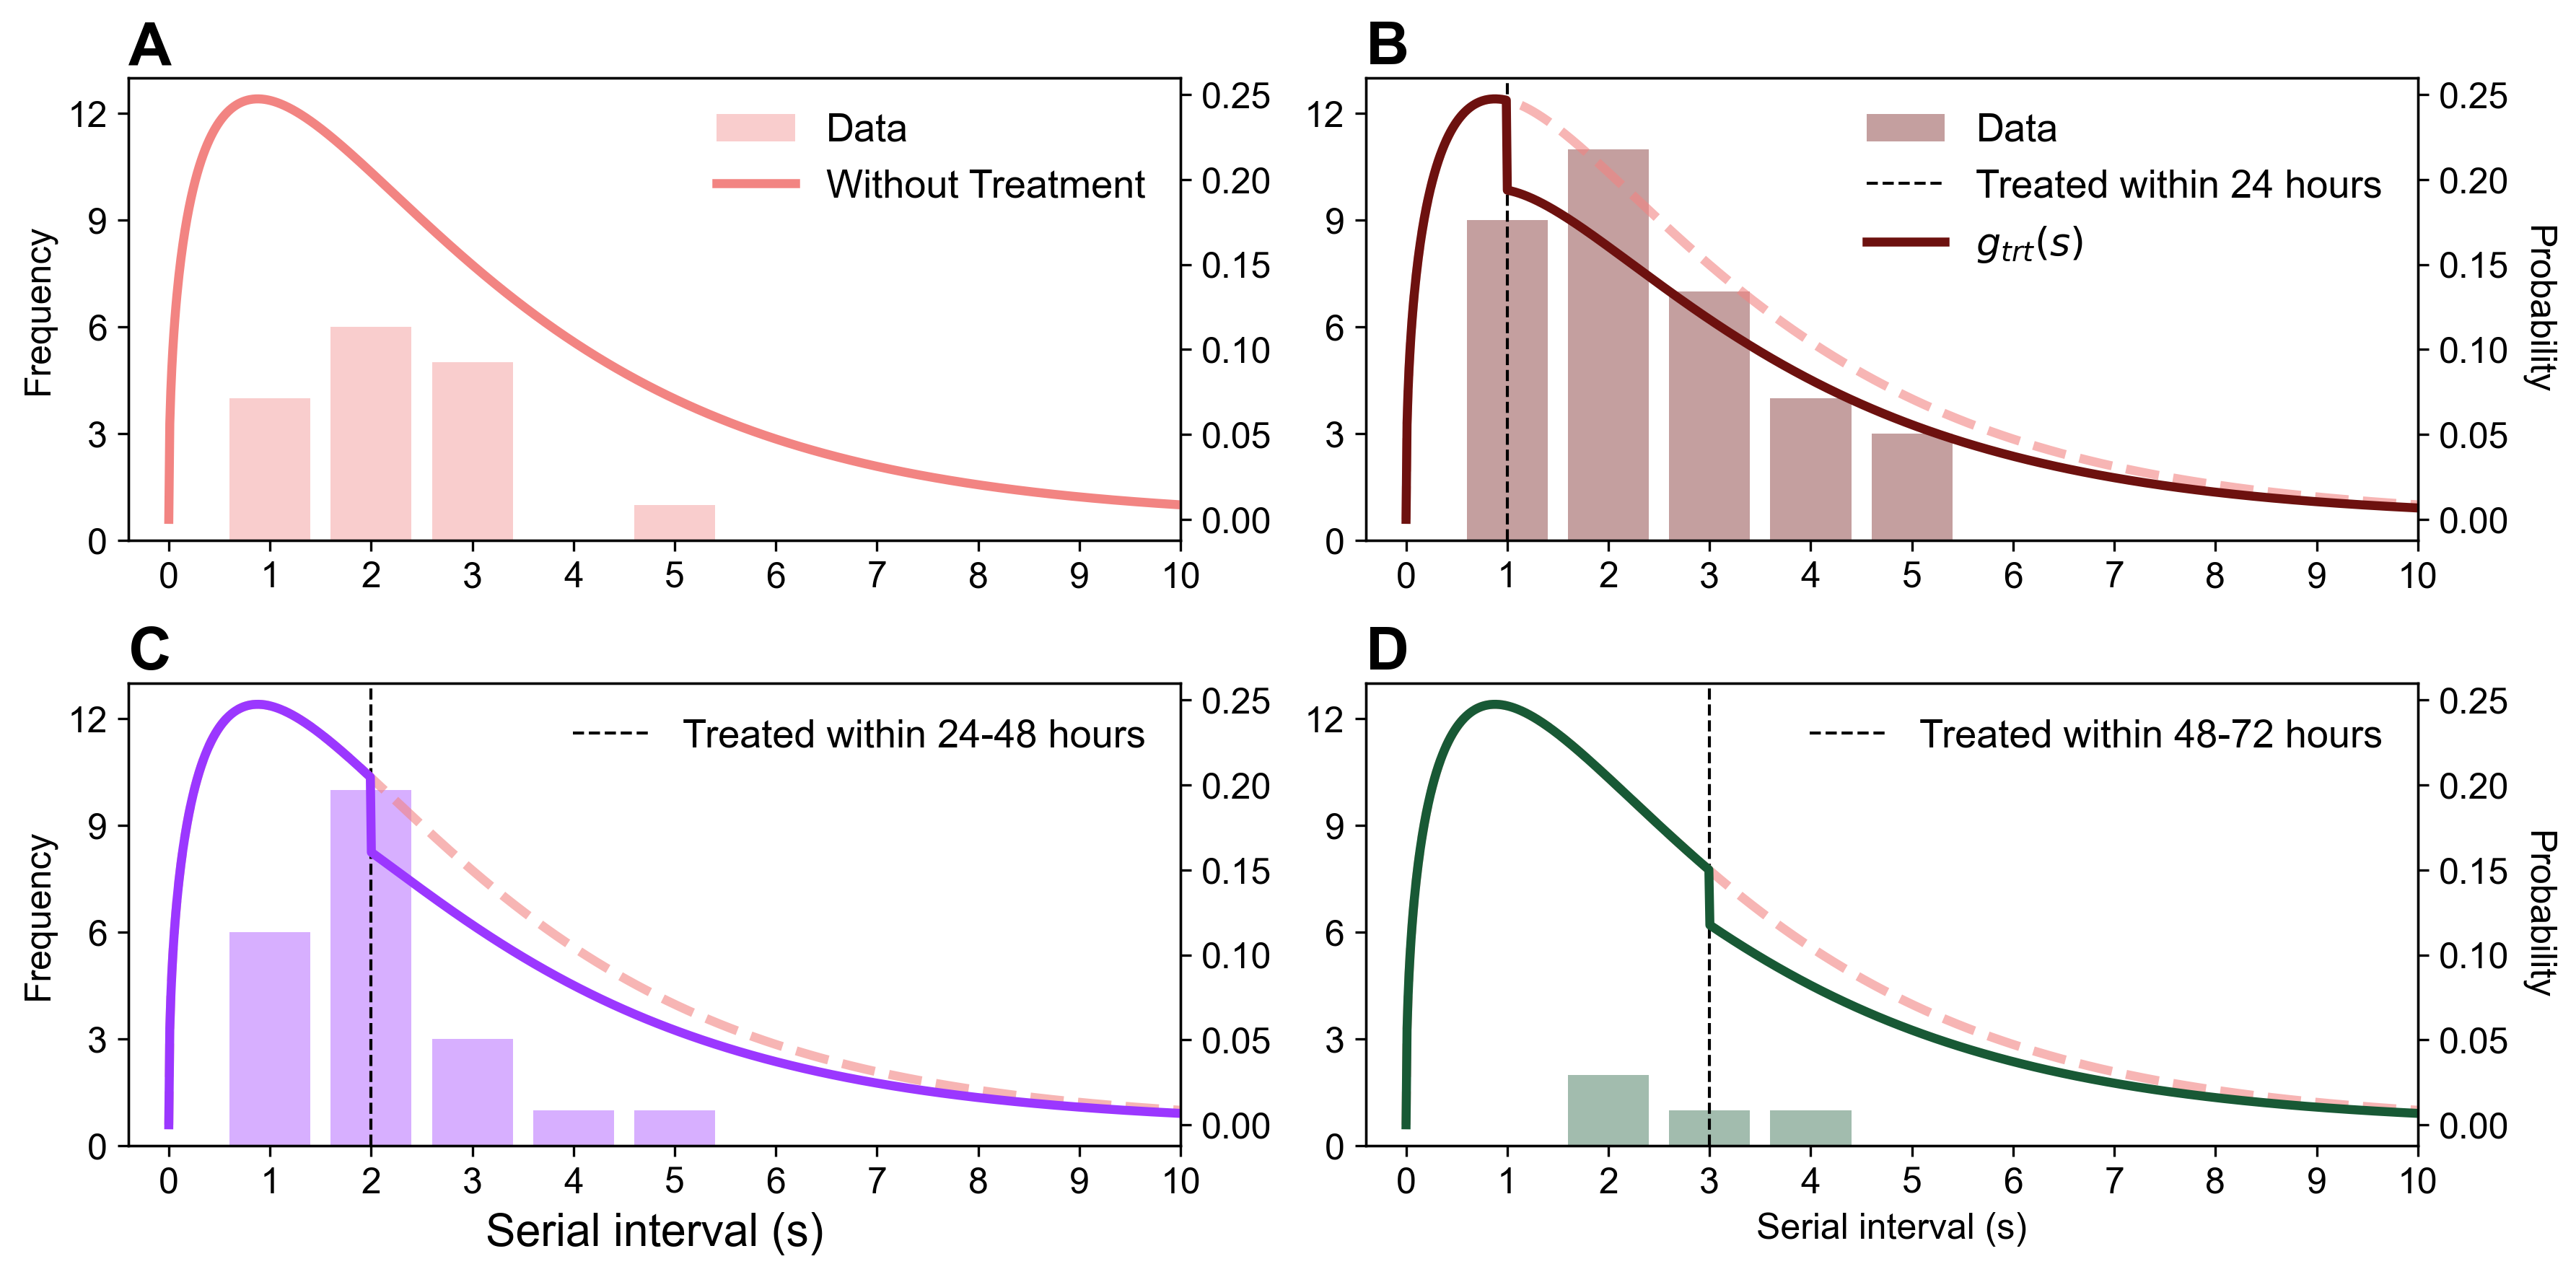

In [ ]:
si_wotrt = si_wotrt[si_wotrt < 6]
si_delay1 = si_delay1[si_delay1 < 6]
si_delay2 = si_delay2[si_delay2 < 6]
si_delay3 = si_delay3[si_delay3 < 6]


fig, axes = plt.subplots(2, 2, figsize=(12, 6), dpi=300)

bins = np.arange(-0.5, 12.5, 1)

# (A) 
axes[0, 0].hist(si_wotrt, bins=bins, density=False, alpha=0.4, 
          color=color_list[1], label='Data', 
          align='mid', rwidth=0.8)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_xticks(range(0, 11))
axes[0, 0].set_xlim(-0.4, 10)
axes[0, 0].set_ylim(0, 13)
axes[0, 0].set_yticks(np.arange(0, 14, 3))
axes[0, 0].tick_params(axis='x', labelsize=12)
axes[0, 0].tick_params(axis='y', labelsize=12)
axes[0, 0].text(0,1.03,'{}'.format(string.ascii_uppercase[0]), transform=axes[0, 0].transAxes, weight='bold', fontsize=20)

ax0 = axes[0, 0].twinx()
ax0.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[0]]['density'], label='Without Treatment', color=color_list[1], linewidth=3)
ax0.tick_params(axis='y', labelsize=12)
h1, l1 = axes[0, 0].get_legend_handles_labels()
h2, l2 = ax0.get_legend_handles_labels()
axes[0, 0].legend(h1 + h2, l1 + l2, loc='upper right', fontsize=13, frameon=False)


# (B) 
axes[0, 1].hist(si_delay1, bins=bins, density=False, alpha=0.4, color=plot_color[0], label='Data',  align='mid', rwidth=0.8)
axes[0, 1].axvline(1, color='black', linewidth=1, linestyle='--', label="Treated within 24 hours")
axes[0, 1].set_xticks(range(0, 11))
axes[0, 1].set_xlim(-0.4, 10)
axes[0, 1].set_ylim(0, 13)
axes[0, 1].set_yticks(np.arange(0, 14, 3))
axes[0, 1].tick_params(axis='x', labelsize=12)
axes[0, 1].tick_params(axis='y', labelsize=12)
axes[0, 1].text(0,1.03,'{}'.format(string.ascii_uppercase[1]), transform=axes[0, 1].transAxes, weight='bold', fontsize=20)

ax1 = axes[0, 1].twinx()
ax1.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[0]]['density'], color=color_list[1], linewidth=3, alpha=0.6, linestyle='--')
ax1.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[1]]['density'], label=plot_title[0], color=plot_color[0], linewidth=3)
ax1.set_ylabel('Probability', fontsize=12, rotation=270, labelpad=15)
ax1.tick_params(axis='y', labelsize=12)
h1, l1 = axes[0, 1].get_legend_handles_labels()
h2, l2 = ax1.get_legend_handles_labels()
axes[0, 1].legend(h1 + h2, l1 + l2, loc='upper right', fontsize=13, frameon=False)


# (C)
axes[1, 0].hist(si_delay2, bins=bins, density=False, alpha=0.4, color=plot_color[1], align='mid', rwidth=0.8) # label='Data',
axes[1, 0].axvline(2, color='black', linewidth=1, label="Treated within 24-48 hours", linestyle='--') #  
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_xticks(range(0, 11))
axes[1, 0].set_xlabel('Serial interval (s)', fontsize=12)
axes[1, 0].set_xlim(-0.4, 10)
axes[1, 0].set_ylim(0, 13)
axes[1, 0].set_yticks(np.arange(0, 14, 3))
axes[1, 0].tick_params(axis='x', labelsize=12)
axes[1, 0].tick_params(axis='y', labelsize=12)
axes[1, 0].set_xlabel('Serial interval (s)', fontsize=15)
axes[1, 0].text(0,1.03,'{}'.format(string.ascii_uppercase[2]), transform=axes[1, 0].transAxes, weight='bold', fontsize=20)

ax2 = axes[1, 0].twinx()
ax2.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[0]]['density'], color=color_list[1], linewidth=3, alpha=0.6, linestyle='--')
ax2.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[2]]['density'], label=plot_title[1], color=plot_color[1], linewidth=3)
ax2.tick_params(axis='y', labelsize=12)
h1, l1 = axes[1, 0].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1, 0].legend(h1, l1, loc='upper right', fontsize=13, frameon=False)


# (D)
axes[1, 1].hist(si_delay3, bins=bins, density=False, alpha=0.4, color=plot_color[2], align='mid', rwidth=0.8) # label='Data', 
axes[1, 1].axvline(3, color='black', linewidth=1, label="Treated within 48-72 hours", linestyle='--') #  
axes[1, 1].set_xticks(range(0, 11))
axes[1, 1].set_xlabel('Serial interval (s)', fontsize=12)
axes[1, 1].set_xlim(-0.4, 10)
axes[1, 1].set_ylim(0, 13)
axes[1, 1].set_yticks(np.arange(0, 14, 3))
axes[1, 1].tick_params(axis='x', labelsize=12)
axes[1, 1].tick_params(axis='y', labelsize=12)
axes[1, 1].set_xlabel('Serial interval (s)', fontsize=12)
axes[1, 1].text(0,1.03,'{}'.format(string.ascii_uppercase[3]), transform=axes[1, 1].transAxes, weight='bold', fontsize=20)

ax3 = axes[1, 1].twinx()
ax3.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[0]]['density'], color=color_list[1], linewidth=3, alpha=0.6, linestyle='--')
ax3.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[3]]['density'], label=plot_title[2], color=plot_color[2], linewidth=3)
ax3.set_ylabel('Probability', fontsize=12, rotation=270, labelpad=15)
ax3.tick_params(axis='y', labelsize=12)
h1, l1 = axes[1, 1].get_legend_handles_labels()
h2, l2 = ax3.get_legend_handles_labels()
axes[1, 1].legend(h1, l1, loc='upper right', fontsize=13, frameon=False)



plt.tight_layout()
plt.show()

fig.savefig(savefolder+'Fig2.png', format='png', bbox_inches='tight', pad_inches=.1, dpi=set_dpi)

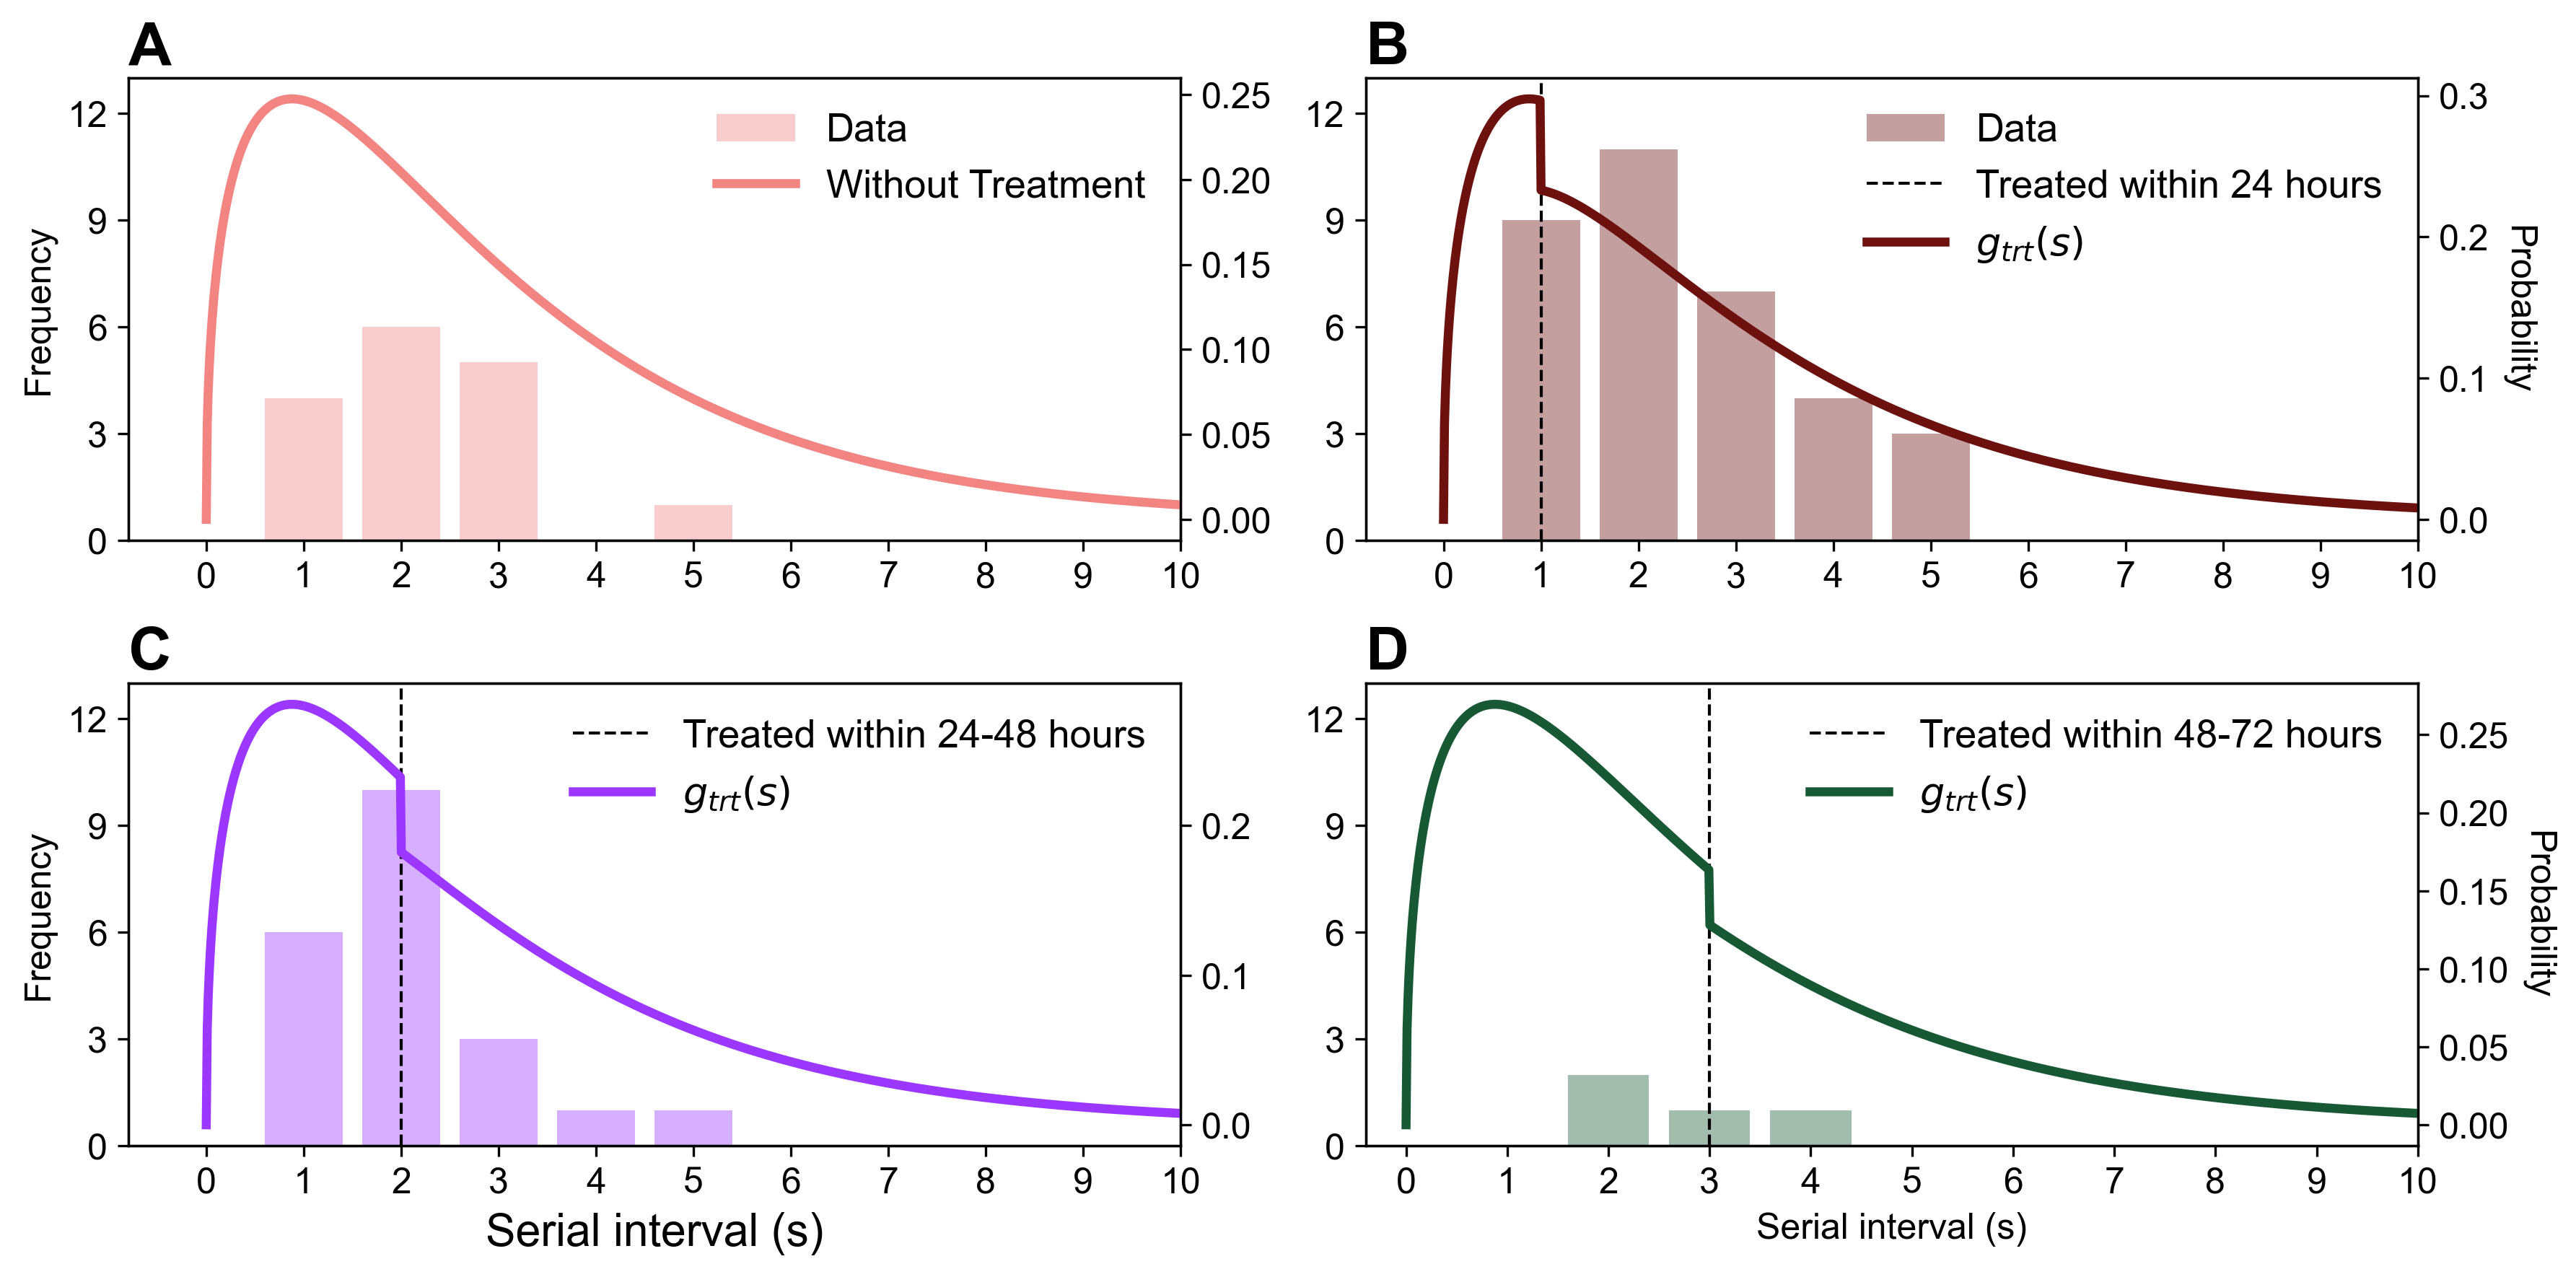

In [ ]:
# normalized version

fig, axes = plt.subplots(2, 2, figsize=(12, 6), dpi=300)

bins = np.arange(-0.5, 12.5, 1)

# (A) 
axes[0, 0].hist(si_wotrt, bins=bins, density=False, alpha=0.4, 
          color=color_list[1], label='Data', 
          align='mid', rwidth=0.8)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_xticks(range(0, 11))
axes[0, 0].set_xlim(-0.8, 10)
axes[0, 0].set_ylim(0, 13)
axes[0, 0].set_yticks(np.arange(0, 14, 3))
axes[0, 0].tick_params(axis='x', labelsize=12)
axes[0, 0].tick_params(axis='y', labelsize=12)
axes[0, 0].text(0,1.03,'{}'.format(string.ascii_uppercase[0]), transform=axes[0, 0].transAxes, weight='bold', fontsize=20)

ax0 = axes[0, 0].twinx()
ax0.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[0]]['density_norm'], label='Without Treatment', color=color_list[1], linewidth=3)
ax0.tick_params(axis='y', labelsize=12)
h1, l1 = axes[0, 0].get_legend_handles_labels()
h2, l2 = ax0.get_legend_handles_labels()
axes[0, 0].legend(h1 + h2, l1 + l2, loc='upper right', fontsize=13, frameon=False)


# (B) 
axes[0, 1].hist(si_delay1, bins=bins, density=False, alpha=0.4, color=plot_color[0], label='Data',  align='mid', rwidth=0.8)
axes[0, 1].axvline(1, color='black', linewidth=1, linestyle='--', label="Treated within 24 hours")
axes[0, 1].set_xticks(range(0, 11))
axes[0, 1].set_xlim(-0.8, 10)
axes[0, 1].set_ylim(0, 13)
axes[0, 1].set_yticks(np.arange(0, 14, 3))
axes[0, 1].tick_params(axis='x', labelsize=12)
axes[0, 1].tick_params(axis='y', labelsize=12)
# axes[0, 1].set_xlabel('Serial interval (s)', fontsize=15)
axes[0, 1].text(0,1.03,'{}'.format(string.ascii_uppercase[1]), transform=axes[0, 1].transAxes, weight='bold', fontsize=20)

ax1 = axes[0, 1].twinx()
# ax1.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[0]]['density_norm'], color=color_list[1], linewidth=3, alpha=0.6, linestyle='--')
ax1.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[1]]['density_norm'], label=plot_title[0], color=plot_color[0], linewidth=3)
ax1.set_ylabel('Probability', fontsize=12, rotation=270, labelpad=15)
ax1.tick_params(axis='y', labelsize=12)
h1, l1 = axes[0, 1].get_legend_handles_labels()
h2, l2 = ax1.get_legend_handles_labels()
axes[0, 1].legend(h1 + h2, l1 + l2, loc='upper right', fontsize=13, frameon=False)


# (C) 
axes[1, 0].hist(si_delay2, bins=bins, density=False, alpha=0.4, color=plot_color[1], align='mid', rwidth=0.8)
axes[1, 0].axvline(2, color='black', linewidth=1, label="Treated within 24-48 hours", linestyle='--') #  
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_xticks(range(0, 11))
axes[1, 0].set_xlabel('Serial interval (s)', fontsize=12)
axes[1, 0].set_xlim(-0.8, 10)
axes[1, 0].set_ylim(0, 13)
axes[1, 0].set_yticks(np.arange(0, 14, 3))
axes[1, 0].tick_params(axis='x', labelsize=12)
axes[1, 0].tick_params(axis='y', labelsize=12)
axes[1, 0].set_xlabel('Serial interval (s)', fontsize=15)
axes[1, 0].text(0,1.03,'{}'.format(string.ascii_uppercase[2]), transform=axes[1, 0].transAxes, weight='bold', fontsize=20)

ax2 = axes[1, 0].twinx()
ax2.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[2]]['density_norm'], label=plot_title[1], color=plot_color[1], linewidth=3)
ax2.tick_params(axis='y', labelsize=12)
h1, l1 = axes[1, 0].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1, 0].legend(h1 + h2, l1 + l2, loc='upper right', fontsize=13, frameon=False)


# (D) 
axes[1, 1].hist(si_delay3, bins=bins, density=False, alpha=0.4, color=plot_color[2], align='mid', rwidth=0.8) 
axes[1, 1].axvline(3, color='black', linewidth=1, label="Treated within 48-72 hours", linestyle='--') #  
axes[1, 1].set_xticks(range(0, 11))
axes[1, 1].set_xlabel('Serial interval (s)', fontsize=12)
axes[1, 1].set_xlim(-0.4, 10)
axes[1, 1].set_ylim(0, 13)
axes[1, 1].set_yticks(np.arange(0, 14, 3))
axes[1, 1].tick_params(axis='x', labelsize=12)
axes[1, 1].tick_params(axis='y', labelsize=12)
axes[1, 1].set_xlabel('Serial interval (s)', fontsize=12)
axes[1, 1].text(0,1.03,'{}'.format(string.ascii_uppercase[3]), transform=axes[1, 1].transAxes, weight='bold', fontsize=20)

ax3 = axes[1, 1].twinx()
ax3.plot(x, df_all_combined[df_all_combined['Type'] == plot_type[3]]['density_norm'], label=plot_title[2], color=plot_color[2], linewidth=3)
ax3.set_ylabel('Probability', fontsize=12, rotation=270, labelpad=15)
ax3.tick_params(axis='y', labelsize=12)
h1, l1 = axes[1, 1].get_legend_handles_labels()
h2, l2 = ax3.get_legend_handles_labels()
axes[1, 1].legend(h1 + h2, l1 + l2, loc='upper right', fontsize=13, frameon=False)



plt.tight_layout()
plt.show()

fig.savefig(savefolder+'FigS3.png', format='png', bbox_inches='tight', pad_inches=.1, dpi=set_dpi)